# Receive DSP chain: 176.4 kHz vs 192 kHz

Compares the per-stage sweep files produced by the `ReceiveChain176k` test suite
(`176k_*.txt`, generated at Fs = 176.4 kHz / audio rate 22.05 kHz) against the
192 kHz sweeps from the `SignalProcessing` suite (audio rate 24 kHz).

Several stages used to carry coefficient tables designed offline for 24 kHz
audio. Run at 22.05 kHz, every corner and centre frequency in them scaled by
176400/192000 = 0.91875. They are now generated from an analog design spec on
every sample rate change, so the two rates should lie on top of each other.

The second half of this notebook compares the generated filters against those
original tables, which are kept in `code/test/reference_filters.cpp`.

Regenerate the data with:

```bash
cd code/test/build && cmake ../ && make all_SigProc_tests all_FilterDesign_tests
./all_SigProc_tests && ./all_FilterDesign_tests
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt

RATE_RATIO = 176400 / 192000   # 0.91875

def load_sweep(path):
    """Return (freq_Hz, gain_linear) from a WriteIQFile sweep: idx,freq,gain."""
    d = np.genfromtxt(path, delimiter=',')
    return d[:, 1], d[:, 2]

def minus6dB_cutoff(f, g):
    """First frequency where |gain| falls to half the passband (first-sample) value."""
    target = 0.5 * g[0]
    below = np.where(g <= target)[0]
    if len(below) == 0:
        return np.nan
    i = below[0]
    if i == 0:
        return f[0]
    # linear interpolation between i-1 and i
    return f[i-1] + (target - g[i-1]) * (f[i] - f[i-1]) / (g[i] - g[i-1])

def peak_freq(f, g):
    return f[int(np.argmax(g))]

## CW audio filters

The five selectable CW bandwidths: 12-pole Chebyshev type I, 0.02 dB ripple.
Solid = 192 kHz, dashed = 176.4 kHz. The pairs should be indistinguishable.


  filter   192k -6dB   176k -6dB    ratio  (expected 0.9187)
 0.8 kHz       852.6       852.5   1.0000
 1.0 kHz      1093.9      1093.8   0.9999
 1.3 kHz      1338.2      1337.9   0.9998
 1.8 kHz      1823.4      1822.8   0.9997
 2.0 kHz      2065.4      2064.5   0.9996


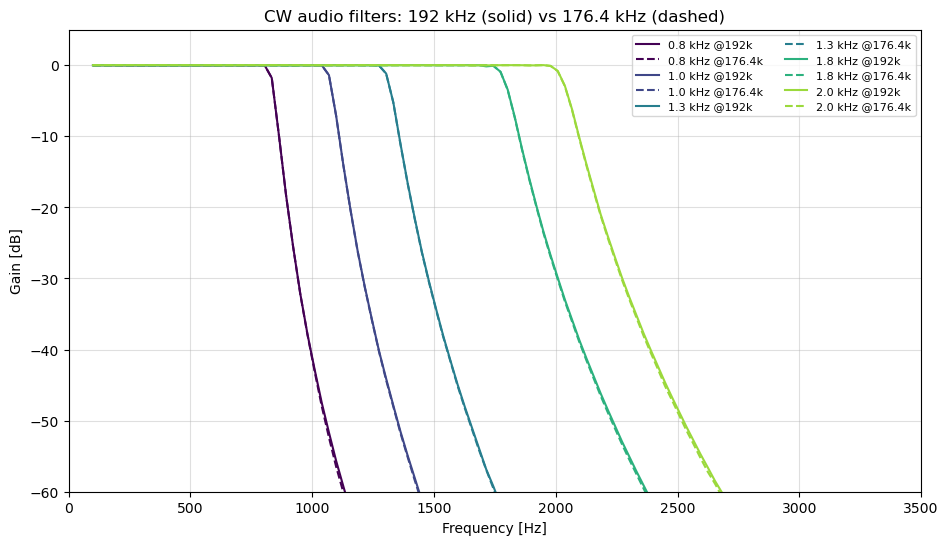

In [2]:
cw_labels = ['0.8 kHz', '1.0 kHz', '1.3 kHz', '1.8 kHz', '2.0 kHz']
colors = plt.cm.viridis(np.linspace(0, 0.85, 5))

plt.figure(figsize=(11, 6))
print(f"{'filter':>8}  {'192k -6dB':>10}  {'176k -6dB':>10}  {'ratio':>7}  (expected {RATE_RATIO:.4f})")
for bf in range(5):
    f0, g0 = load_sweep('build/CWFilter_band_%d.txt' % bf)
    f1, g1 = load_sweep('build/176k_CWFilter_band_%d.txt' % bf)
    plt.plot(f0, 20*np.log10(g0), '-',  color=colors[bf], label='%s @192k' % cw_labels[bf])
    plt.plot(f1, 20*np.log10(g1), '--', color=colors[bf], label='%s @176.4k' % cw_labels[bf])
    c0, c1 = minus6dB_cutoff(f0, g0), minus6dB_cutoff(f1, g1)
    print(f"{cw_labels[bf]:>8}  {c0:10.1f}  {c1:10.1f}  {c1/c0:7.4f}")

plt.ylim(-60, 5)
plt.xlim(0, 3500)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=8, ncol=2)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('CW audio filters: 192 kHz (solid) vs 176.4 kHz (dashed)')
plt.show()

## Receive EQ bands

All 14 graphic-EQ cells. Each cell should peak on its labelled centre at both
rates.

These sweeps run on a ~20 Hz grid, so a peak that falls between two grid points
can read one step off and show a ratio like 1.016 or 0.994. That is the sweep
resolution, not a shift: the precise measurement in `filtercmp_rate_summary.txt`
further down reads 1.0000 for all 14 cells.


band   192k peak   176k peak    ratio
   0       198.5       198.5   1.0000
   1       257.6       257.6   1.0000
   2       316.7       316.7   1.0000
   3       395.5       395.5   1.0000
   4       494.0       494.0   1.0000
   5       631.9       631.9   1.0000
   6       789.5       789.5   1.0000
   7      1006.2      1006.2   1.0000
   8      1242.6      1262.3   1.0159
   9      1597.3      1597.3   1.0000
  10      1991.3      1991.3   1.0000
  11      2503.5      2503.5   1.0000
  12      3153.6      3133.9   0.9938
  13      4000.7      4000.7   1.0000


/tmp/ipykernel_1550931/2527797174.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(f1, 20*np.log10(g1), '--', color=colors[bf])
/tmp/ipykernel_1550931/2527797174.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(f0, 20*np.log10(g0), '-',  color=colors[bf])


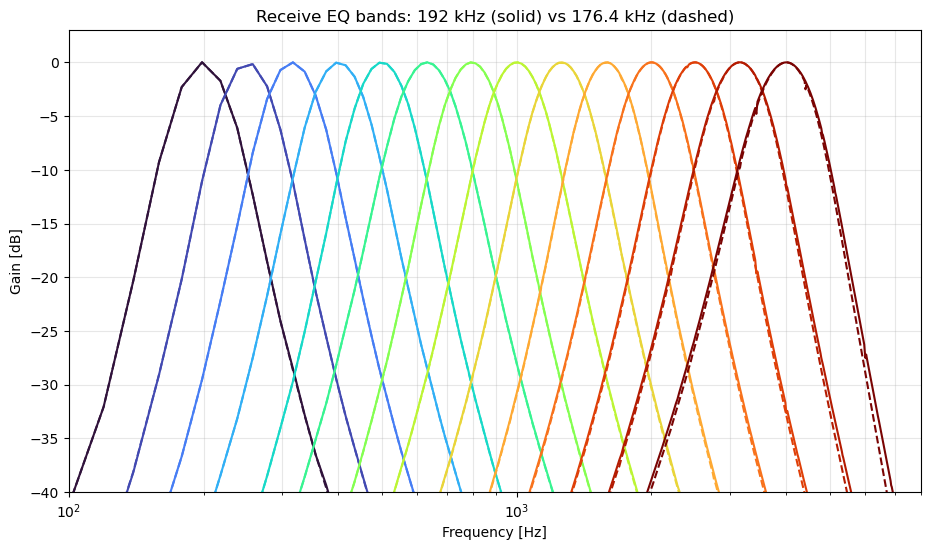

In [3]:
plt.figure(figsize=(11, 6))
colors = plt.cm.turbo(np.linspace(0, 1, 14))
print(f"{'band':>4}  {'192k peak':>10}  {'176k peak':>10}  {'ratio':>7}")
for bf in range(14):
    f0, g0 = load_sweep('build/ReceiveEQ_band_%d.txt' % bf)
    f1, g1 = load_sweep('build/176k_ReceiveEQ_band_%d.txt' % bf)
    plt.semilogx(f0, 20*np.log10(g0), '-',  color=colors[bf])
    plt.semilogx(f1, 20*np.log10(g1), '--', color=colors[bf])
    p0, p1 = peak_freq(f0, g0), peak_freq(f1, g1)
    print(f"{bf:>4}  {p0:10.1f}  {p1:10.1f}  {p1/p0:7.4f}")

plt.ylim(-40, 3)
plt.xlim(100, 8000)
plt.grid(True, which='both', alpha=0.3)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('Receive EQ bands: 192 kHz (solid) vs 176.4 kHz (dashed)')
plt.show()

### EQ top band zoom

The 4000 Hz cell is where the old shift was largest (it landed at 3675 Hz).


/tmp/ipykernel_1550931/1314273394.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.plot(f0, 20*np.log10(g0), 'k-',  label='192 kHz  (peak %.0f Hz)' % p0)


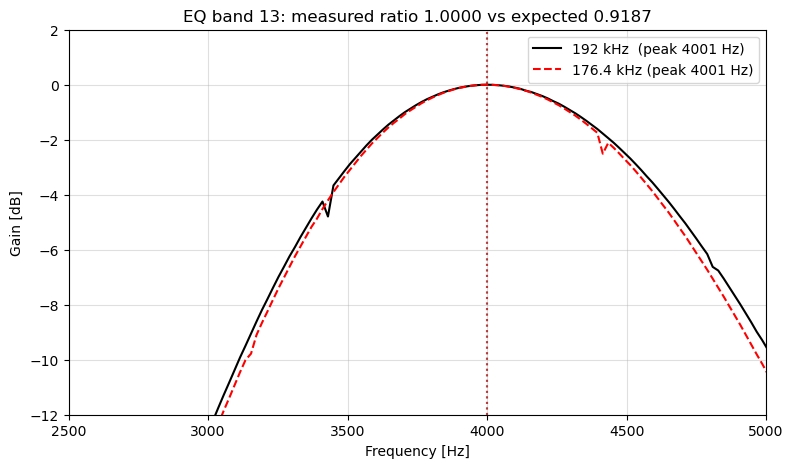

In [4]:
bf = 13
f0, g0 = load_sweep('build/ReceiveEQ_band_%d.txt' % bf)
f1, g1 = load_sweep('build/176k_ReceiveEQ_band_%d.txt' % bf)
p0, p1 = peak_freq(f0, g0), peak_freq(f1, g1)

plt.figure(figsize=(9, 5))
plt.plot(f0, 20*np.log10(g0), 'k-',  label='192 kHz  (peak %.0f Hz)' % p0)
plt.plot(f1, 20*np.log10(g1), 'r--', label='176.4 kHz (peak %.0f Hz)' % p1)
plt.axvline(p0, color='k', ls=':', alpha=0.5)
plt.axvline(p1, color='r', ls=':', alpha=0.5)
plt.xlim(2500, 5000)
plt.ylim(-12, 2)
plt.grid(True, alpha=0.4)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('EQ band 13: measured ratio %.4f vs expected %.4f' % (p1/p0, RATE_RATIO))
plt.show()

## AM audio lowpass IIR

This stage always recomputed its coefficients from the sample rate, so it served
as the control while the others were being fixed. The two curves should lie
almost on top of each other.


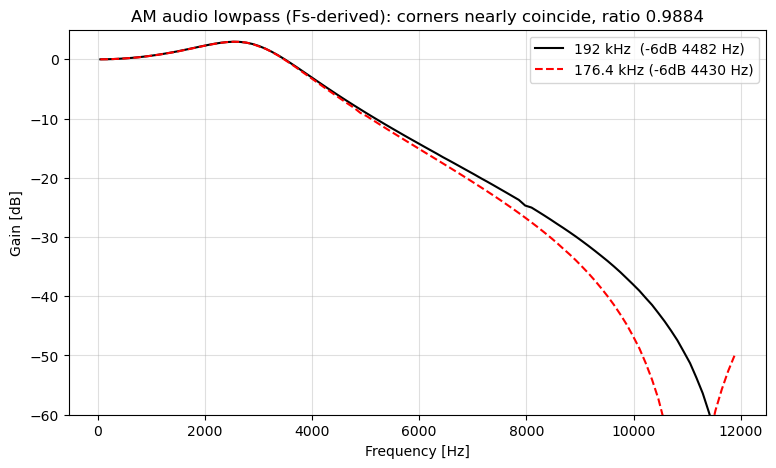

In [5]:
f0, g0 = load_sweep('build/AudioIIRPassband.txt')
f1, g1 = load_sweep('build/176k_AudioIIRPassband.txt')
c0, c1 = minus6dB_cutoff(f0, g0), minus6dB_cutoff(f1, g1)

plt.figure(figsize=(9, 5))
plt.plot(f0, 20*np.log10(g0), 'k-',  label='192 kHz  (-6dB %.0f Hz)' % c0)
plt.plot(f1, 20*np.log10(g1), 'r--', label='176.4 kHz (-6dB %.0f Hz)' % c1)
plt.ylim(-60, 5)
plt.grid(True, alpha=0.4)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Gain [dB]')
plt.title('AM audio lowpass (Fs-derived): corners nearly coincide, ratio %.4f' % (c1/c0))
plt.show()

## Summary

The `176k_stage_shift_summary.txt` file written by the test, plus a bar chart of
the measured ratio per stage. Every bar should now sit on the 1.0 line; the
0.91875 line marks where the CW and EQ bars used to be.


[('CW_audio_filter_2k0_upper_cutoff', 'fs_derived', 2064.6, 2063.7, 0.9996, 1.)
 ('EQ_band13_4000_peak', 'fs_derived', 4000. , 4000. , 1.    , 1.)
 ('AM_audio_lowpass_corner', 'fs_derived', 4475.9, 4425.8, 0.9888, 1.)]


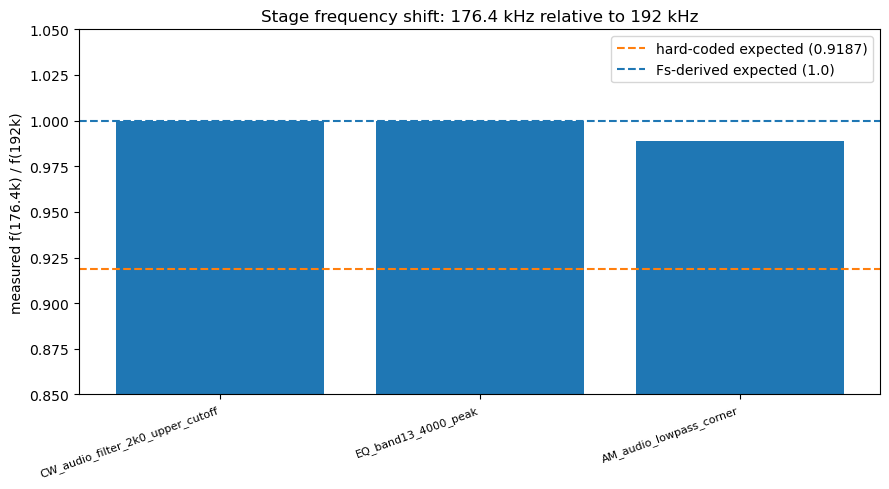

In [6]:
rows = np.genfromtxt('build/176k_stage_shift_summary.txt', delimiter=',',
                     names=True, dtype=None, encoding='utf-8')
print(rows)

labels = [r['stage'] for r in rows]
measured = np.array([r['measured_ratio'] for r in rows])
types = [r['type'] for r in rows]
bar_colors = ['tab:orange' if t == 'hardcoded' else 'tab:blue' for t in types]

plt.figure(figsize=(9, 5))
x = np.arange(len(labels))
plt.bar(x, measured, color=bar_colors)
plt.axhline(RATE_RATIO, color='tab:orange', ls='--', label='hard-coded expected (%.4f)' % RATE_RATIO)
plt.axhline(1.0, color='tab:blue', ls='--', label='Fs-derived expected (1.0)')
plt.xticks(x, labels, rotation=20, ha='right', fontsize=8)
plt.ylim(0.85, 1.05)
plt.ylabel('measured f(176.4k) / f(192k)')
plt.title('Stage frequency shift: 176.4 kHz relative to 192 kHz')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

* **CW audio filters** and **EQ bands** now hold their frequencies across the
  rate change. Their coefficients are regenerated from an analog design spec
  whenever the sample rate changes, so the ratio reads 1.00 instead of 0.91875.
* **The AM audio lowpass** behaves as it always did — it was Fs-derived from the
  start.

The remaining cells check the other half of the question: that regenerating
these filters reproduced what the frozen tables actually did.


---

# Generated filters vs the tables they replace

`FilterDesign_test.cpp` sweeps each stage twice at 192 kHz — once with the
generated coefficients, once with the original frozen table from
`reference_filters.cpp` — and writes both curves. If the redesign was faithful,
the pairs overlie each other and the difference traces sit on zero.


In [7]:
def load_pair(stem):
    """Load the generated and reference sweeps for one stage.

    FilterDesign_test writes gain already in dB, unlike the linear-gain sweeps
    the ReceiveChain176k tests produce.
    """
    fg, gg = load_sweep('build/filtercmp_%s_gen.txt' % stem)
    fr, gr = load_sweep('build/filtercmp_%s_ref.txt' % stem)
    return fg, gg, fr, gr


def plot_generated_vs_reference(stems, labels, title, cmap, floor_dB=-90):
    fig, (ax, axd) = plt.subplots(2, 1, figsize=(11, 8), sharex=False,
                                  gridspec_kw={'height_ratios': [3, 1]})
    colors = cmap(np.linspace(0, 0.85, len(stems)))
    worst = 0.0
    for stem, label, c in zip(stems, labels, colors):
        fg, gg, fr, gr = load_pair(stem)
        ax.plot(fg, gg, color=c, lw=1.6, label='%s generated' % label)
        ax.plot(fr, gr, color=c, lw=1.0, ls='--', label='%s frozen' % label)
        keep = gr > floor_dB
        diff = gg[keep] - gr[keep]
        axd.plot(fg[keep], diff, color=c, lw=1.2)
        worst = max(worst, np.max(np.abs(diff)))

    ax.set_title('%s  (worst difference %.4f dB)' % (title, worst))
    ax.set_ylabel('gain (dB)')
    ax.set_ylim(floor_dB, 5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
    axd.axhline(0, color='k', lw=0.8)
    axd.set_xlabel('frequency (Hz)')
    axd.set_ylabel('generated\n- frozen (dB)')
    axd.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return worst


## CW audio filters: generated vs frozen

The frozen tables are 12-pole Chebyshev type I with 0.02 dB ripple. The
generator places the same poles in closed form from the ripple edge, so the two
should agree to a few thousandths of a decibel.


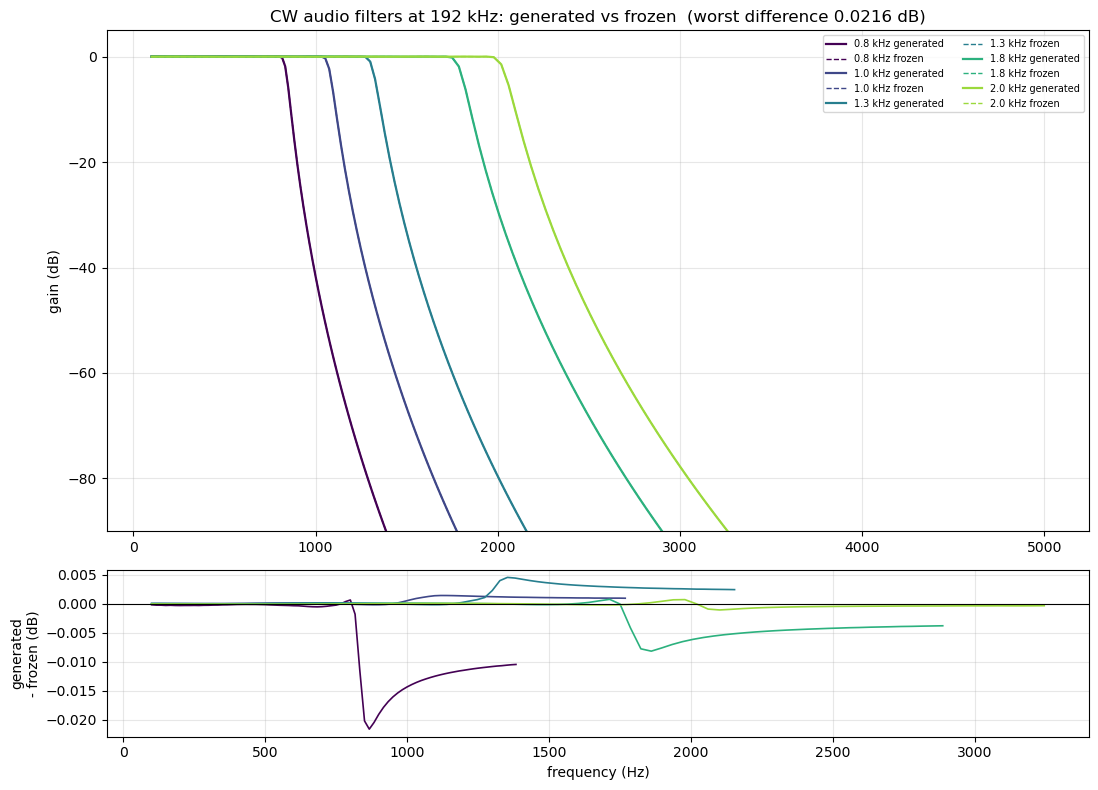

worst CW departure from the frozen Chebyshev: 0.0216 dB (test allows 0.05)


In [8]:
cw_labels = ['0.8 kHz', '1.0 kHz', '1.3 kHz', '1.8 kHz', '2.0 kHz']
worst = plot_generated_vs_reference(
    ['cw_band_%d' % b for b in range(5)],
    cw_labels,
    'CW audio filters at 192 kHz: generated vs frozen',
    plt.cm.viridis)
print('worst CW departure from the frozen Chebyshev: %.4f dB (test allows 0.05)' % worst)


## EQ cells: generated vs frozen

Each cell's analog prototype is recovered from the frozen table by an exact
inverse bilinear transform, so agreement here should be at the level of float32
rounding.


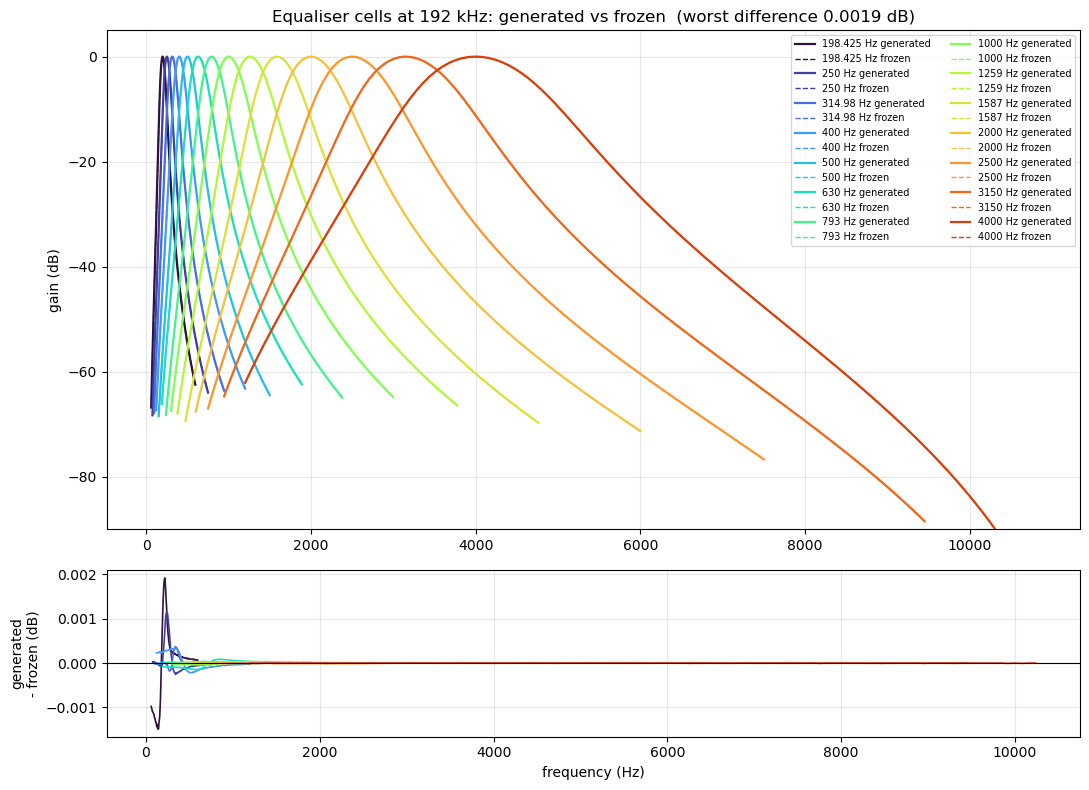

worst EQ departure from the frozen table: 0.001914 dB (test allows 0.01)


In [9]:
eq_fc = [198.425, 250, 314.98, 400, 500, 630, 793,
         1000, 1259, 1587, 2000, 2500, 3150, 4000]
worst = plot_generated_vs_reference(
    ['eq_band_%d' % b for b in range(14)],
    ['%g Hz' % f for f in eq_fc],
    'Equaliser cells at 192 kHz: generated vs frozen',
    plt.cm.turbo)
print('worst EQ departure from the frozen table: %.6f dB (test allows 0.01)' % worst)


## Flat equaliser reconstruction

`BandEQ` sums the 14 cells with alternating sign. With every cell set to 100 the
sum should come out level — this only works if each cell keeps its designed
shape and peak gain, so it is the sharpest check on the redesign.

Note the sum sits near +4 dB rather than 0 dB. That is how the equaliser has
always behaved; the overlapping cells add up to more than unity.


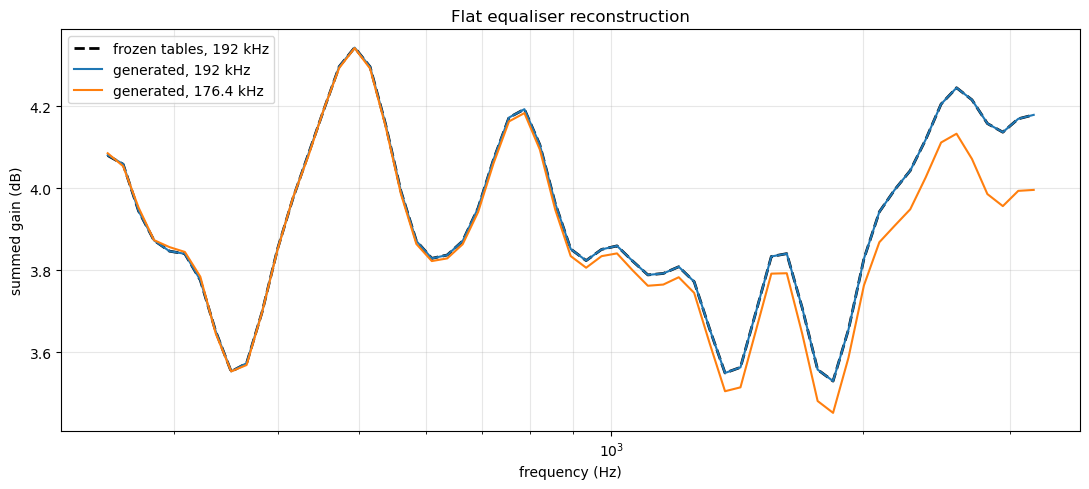

ripple, frozen @192k    : 0.814 dB peak to peak
ripple, generated @192k : 0.814 dB peak to peak
ripple, generated @176k : 0.891 dB peak to peak
max |generated - frozen| at 192 kHz: 0.0008 dB


In [10]:
f_gen192, g_gen192 = load_sweep('build/filtercmp_eq_flatsum_192000_gen.txt')
f_ref192, g_ref192 = load_sweep('build/filtercmp_eq_flatsum_192000_ref.txt')
f_gen176, g_gen176 = load_sweep('build/filtercmp_eq_flatsum_176400_gen.txt')

plt.figure(figsize=(11, 5))
plt.semilogx(f_ref192, g_ref192, 'k--', lw=2.0, label='frozen tables, 192 kHz')
plt.semilogx(f_gen192, g_gen192, lw=1.5, label='generated, 192 kHz')
plt.semilogx(f_gen176, g_gen176, lw=1.5, label='generated, 176.4 kHz')
plt.xlabel('frequency (Hz)')
plt.ylabel('summed gain (dB)')
plt.title('Flat equaliser reconstruction')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

print('ripple, frozen @192k    : %.3f dB peak to peak' % np.ptp(g_ref192))
print('ripple, generated @192k : %.3f dB peak to peak' % np.ptp(g_gen192))
print('ripple, generated @176k : %.3f dB peak to peak' % np.ptp(g_gen176))
print('max |generated - frozen| at 192 kHz: %.4f dB' % np.max(np.abs(g_gen192 - g_ref192)))


## Every generated stage, at both rates

`filtercmp_rate_summary.txt` measures a characteristic frequency of every
generated stage at 192 kHz and 176.4 kHz. Before this work the CW and EQ rows
read 0.9187.


CW_audio_840_minus6dB                 850.5 ->    850.4 Hz   ratio 0.9999
CW_audio_1080_minus6dB               1093.4 ->   1093.3 Hz   ratio 0.9999
CW_audio_1320_minus6dB               1336.3 ->   1336.0 Hz   ratio 0.9998
CW_audio_1800_minus6dB               1821.7 ->   1821.1 Hz   ratio 0.9997
CW_audio_2000_minus6dB               2064.4 ->   2063.5 Hz   ratio 0.9996
EQ_band0_198_peak                     198.4 ->    198.4 Hz   ratio 1.0000
EQ_band1_250_peak                     250.0 ->    250.0 Hz   ratio 1.0000
EQ_band2_315_peak                     315.0 ->    315.0 Hz   ratio 1.0000
EQ_band3_400_peak                     400.0 ->    400.0 Hz   ratio 1.0000
EQ_band4_500_peak                     500.0 ->    500.0 Hz   ratio 1.0000
EQ_band5_630_peak                     630.0 ->    630.0 Hz   ratio 1.0000
EQ_band6_793_peak                     793.0 ->    793.0 Hz   ratio 1.0000
EQ_band7_1000_peak                   1000.0 ->   1000.0 Hz   ratio 1.0000
EQ_band8_1259_peak                   1

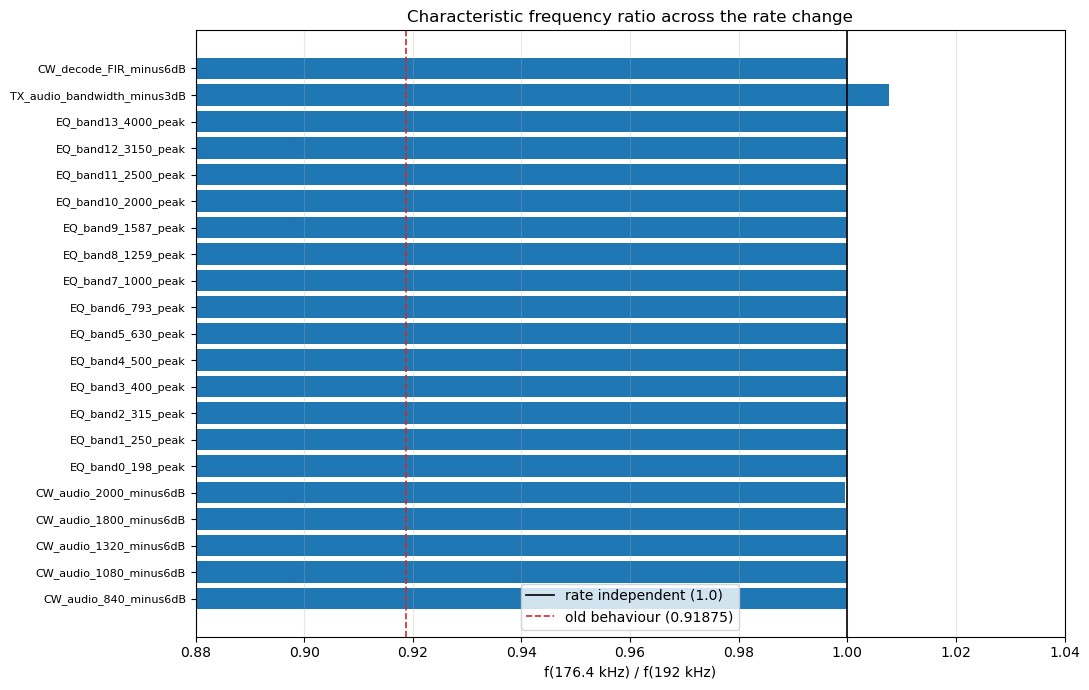


largest departure from 1.0: 0.0077


In [11]:
rows = np.genfromtxt('build/filtercmp_rate_summary.txt', delimiter=',',
                     names=True, dtype=None, encoding='utf-8')

labels = [r['stage'] for r in rows]
ratios = np.array([r['measured_ratio'] for r in rows])

for r in rows:
    print('%-34s %8.1f -> %8.1f Hz   ratio %.4f'
          % (r['stage'], r['f_192k_Hz'], r['f_176k_Hz'], r['measured_ratio']))

plt.figure(figsize=(11, 7))
y = np.arange(len(labels))
plt.barh(y, ratios, color='tab:blue')
plt.axvline(1.0, color='k', lw=1.2, label='rate independent (1.0)')
plt.axvline(RATE_RATIO, color='tab:red', ls='--', lw=1.2,
            label='old behaviour (%.5f)' % RATE_RATIO)
plt.yticks(y, labels, fontsize=8)
plt.xlim(0.88, 1.04)
plt.xlabel('f(176.4 kHz) / f(192 kHz)')
plt.title('Characteristic frequency ratio across the rate change')
plt.grid(alpha=0.3, axis='x')
plt.legend()
plt.tight_layout()
plt.show()

print('\nlargest departure from 1.0: %.4f' % np.max(np.abs(ratios - 1.0)))
